**Rhodium Hydrogenation of Enamides TSFF Parameterized by a new Hybrid Optimizer**

Rh Hyd Enamides TSFF as a test case for the use of a new Hybrid Particle Swarm-Differential Evolution Optimization Algorithm (hybrid_optimizer) developed by Mikaela Farrugia (github: @mmfarrugia) under Olaf Wiest & Paul Helquist.

These are all being run with the pbest localization as convergence criterion.
Note: Score distributions are incorrect due to funky mm3.fld vs mm3.hybrid.fld issue which is now fixed but untested/unrun

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd
from numpy import copy
from scipy import stats
import itertools

seaborn.set_theme(style="whitegrid")

zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080', '#528D6A']
zesty2 = ['#F65300', '#6e3a69', '#6793bc', '#081142', '#39634a'] #c86431
zesty_palette = seaborn.color_palette(palette=zesty)
zesty2_palette = seaborn.color_palette(palette=zesty2)
edges = itertools.cycle(zesty2_palette)
palette = itertools.cycle(zesty_palette)
palette = itertools.cycle(zesty_palette)
edges = itertools.cycle(zesty2_palette)

#src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm/q2mm")
sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.8/site-packages/q2mm-0.0.0-py3.8.egg")

#from hybrid_optimizer import PSO_GA
import q2mm.hybrid_optimizer as hybrid_optimizer
from q2mm.hybrid_optimizer import PSO_DE
from tools.ff_plotting import *



In [2]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]

METHODS


All are done with 8 workers, 10 particles/TSFF candidates, with 0.001 convergence criteria, run for loop cycles of 50 iter maximum with 3 technical replicates run for each case. Further information regarding the settings, files, and parameters used in the optimizations can be found in their respective directories under the README.txt file.

All hyperparameters are derived from literature **INCLUDE REFS** and use the TIGHT_OPT_CONFIG.

In [3]:
num_particles = 10
cycle_iter_length = 50
num_workers = 8
convergence_criteria = 0.001
num_tech_replicates = 3
num_params = 31

**Start: FUERZA estimated FCs + Donoghue charges**

Original Score: 1.36078

In [4]:
# Gather data on starting point

fuerza_score = 1.36077746
score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 1, 106390, 106391, 106392, 106393, 106394, 106395, 106396, 106397, 106398, 106399, 106400, 106401]

qf_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/rh_qf_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=fuerza_score)
# /opt_qstatic_start_hybrid_eig
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]

bond_rows = np.arange(1859, 1867)
angle_rows = np.arange(1867, 1889)

#bond_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.old.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=0)
#angle_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.old.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=0)

bond_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_score)
angle_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_score)




In [5]:
base_directory = '/home/mfarrugi/repos/q2mm/rh-hybrid/conv_crit/local_best_x/500_iter_max_run' #1000_iter_kinda_fails'
cycle_iter_length = 1000
directory_list = ['2', '3', '5'] #['1', '2', '3', '4']

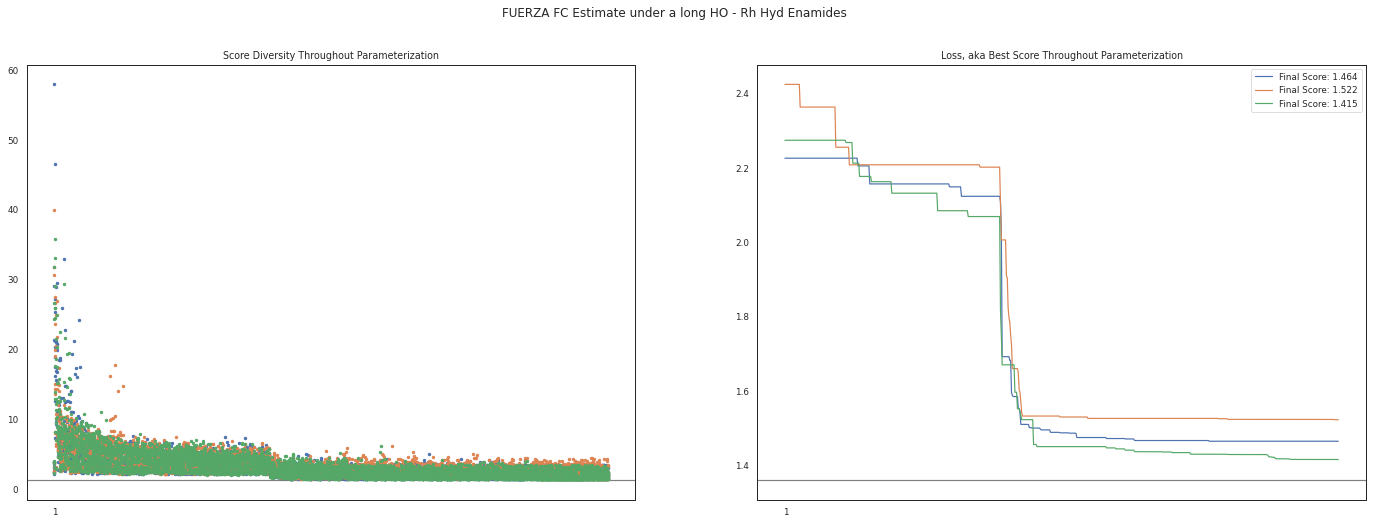

In [6]:
%matplotlib inline
#OLD STUFF
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a long HO - Rh Hyd Enamides')
ax[0].set_title('Score Diversity Throughout Parameterization')
ax[1].set_title('Loss, aka Best Score Throughout Parameterization')

ax[0].axhline(y=fuerza_score, color='gray')
ax[1].axhline(y=fuerza_score, color='gray')

final_scores = []

for directory in [2, 3, 5]:

    swarm_history_file = open(os.path.join('/home/mfarrugi/repos/q2mm/rh-hybrid/conv_crit/local_best_x/500_iter_max_run', str(directory), 'hybrid_opt_history.bin'), 'rb')
    swarm_history = pickle.load(swarm_history_file)
    swarm_history_file.close()
    num_iters = len(swarm_history['Y'])
    num_ffs = len(swarm_history['Y'][0])
    assert num_ffs == num_particles
    color = next(ax[0]._get_lines.prop_cycler)['color']
    Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))
    ax[0].plot(Y_history.index, Y_history.values, '.', color=color)
    loss = Y_history.min(axis=1).cummin()
    loss.plot(kind='line', ax=ax[1], color=color, label='Final Score: '+'{0:.3f}'.format(loss.iloc[-1]))
    # final_scores.append('{0:.3f}'.format(loss.iloc[-1]))
    final_scores.append(loss.iloc[-1])

ax[1].legend()

ax[0].xaxis.set_ticks(np.arange(1, ax[0].get_xlim()[1], cycle_iter_length))
ax[1].xaxis.set_ticks(np.arange(1, ax[0].get_xlim()[1], cycle_iter_length))

plt.show()

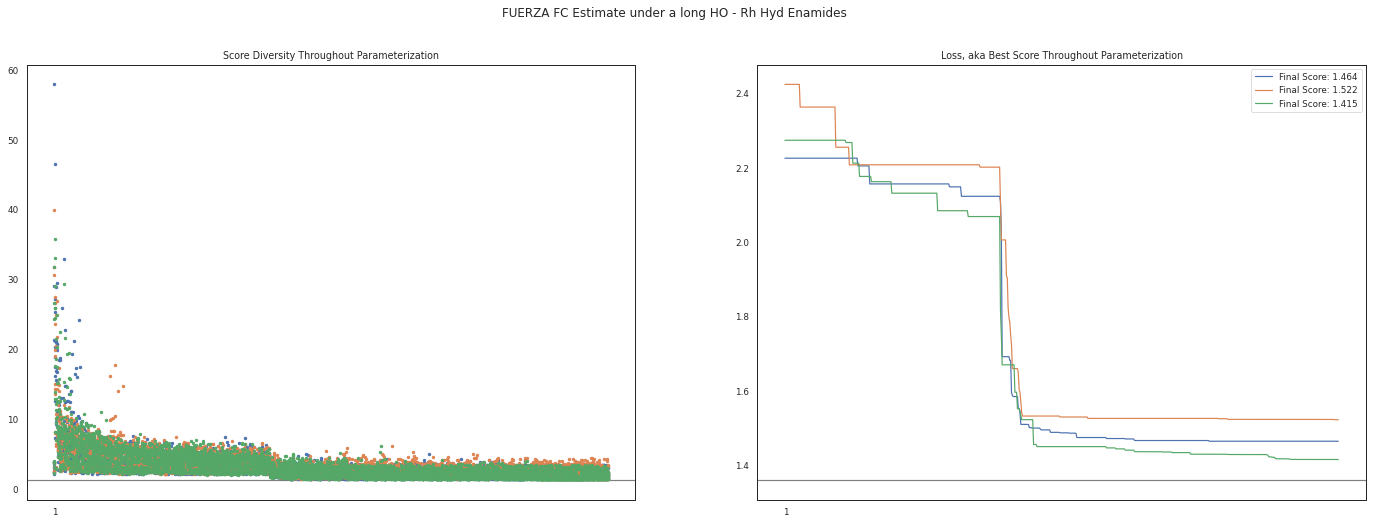

In [7]:
%matplotlib inline
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a long HO - Rh Hyd Enamides')
ax[0].set_title('Score Diversity Throughout Parameterization')
ax[1].set_title('Loss, aka Best Score Throughout Parameterization')

ax[0].axhline(y=fuerza_score, color='gray')
ax[1].axhline(y=fuerza_score, color='gray')

final_scores = []

for directory in directory_list:

    swarm_history_file = open(os.path.join(base_directory, directory, 'hybrid_opt_history.bin'), 'rb')
    swarm_history = pickle.load(swarm_history_file)
    swarm_history_file.close()
    num_iters = len(swarm_history['Y'])
    num_ffs = len(swarm_history['Y'][0])
    assert num_ffs == num_particles
    color = next(ax[0]._get_lines.prop_cycler)['color']
    Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))
    ax[0].plot(Y_history.index, Y_history.values, '.', color=color)
    loss = Y_history.min(axis=1).cummin()
    loss.plot(kind='line', ax=ax[1], color=color, label='Final Score: '+'{0:.3f}'.format(loss.iloc[-1]))
    # final_scores.append('{0:.3f}'.format(loss.iloc[-1]))
    final_scores.append(loss.iloc[-1])

ax[1].legend()

ax[0].xaxis.set_ticks(np.arange(1, ax[0].get_xlim()[1], cycle_iter_length))
ax[1].xaxis.set_ticks(np.arange(1, ax[0].get_xlim()[1], cycle_iter_length))

plt.show()

In [8]:
%matplotlib inline
# Plot Scores

score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
runs = []
for directory, score in zip(directory_list, final_scores):
    runs.append(pd.read_csv(os.path.join(base_directory, directory, 'rh_qf_ho_end.txt'), skiprows=[0, 1, 106390, 106391, 106392, 106393, 106394, 106395, 106396, 106397, 106398, 106399, 106400, 106401], delim_whitespace=True, names=score_cols).assign(FF=score))


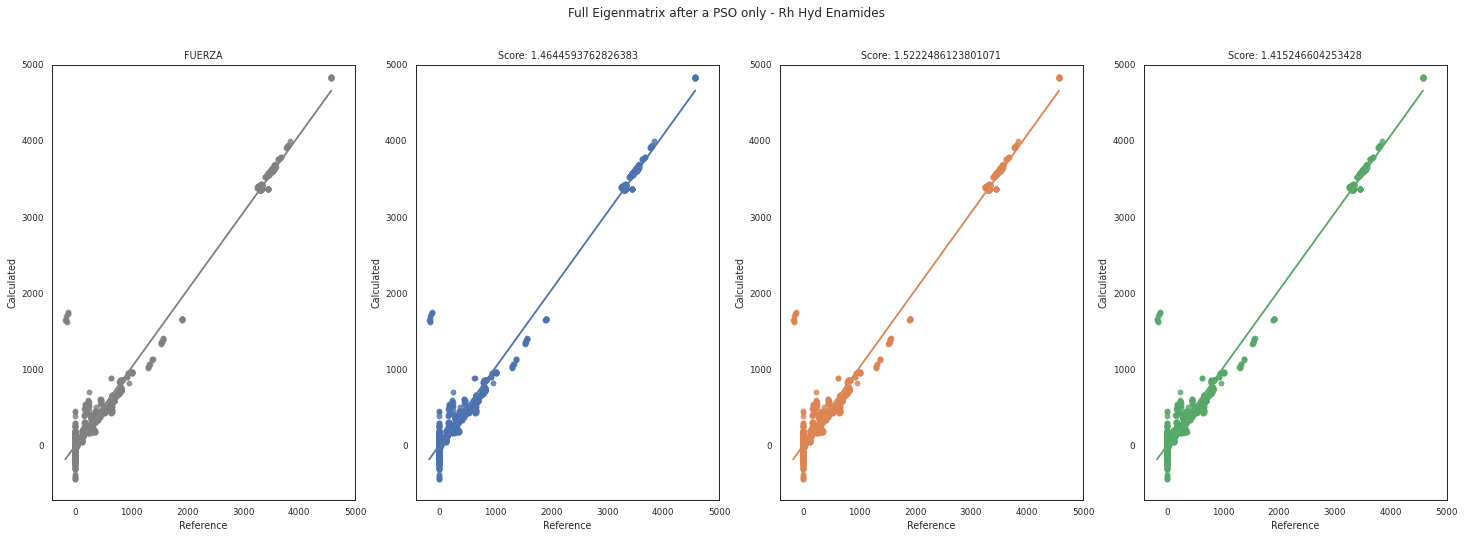

In [9]:
fig, ax = plt.subplots(1, len(runs)+1, figsize=(25, 8))
fig.suptitle('Full Eigenmatrix after a PSO only - Rh Hyd Enamides')
palette = itertools.cycle(seaborn.color_palette())

seaborn.regplot(data=qf_scores, x=score_cols[2], y=score_cols[3], label='FF', fit_reg=True, ax=ax[0], color='gray')
ax[0].set_ylim(top=5000)
ax[0].set_xlim(xmax = 5000)
ax[0].set_title('FUERZA')

for i, run in enumerate(runs):
    color = next(palette)
    seaborn.regplot(data=run, x=score_cols[2], y=score_cols[3], label='FF', fit_reg=True, ax=ax[i+1], color=color)

    ax[i+1].set_ylim(top=5000)
    ax[i+1].set_xlim(xmax = 5000)
    ax[i+1].set_title('Score: '+str(final_scores[i]))

plt.show()

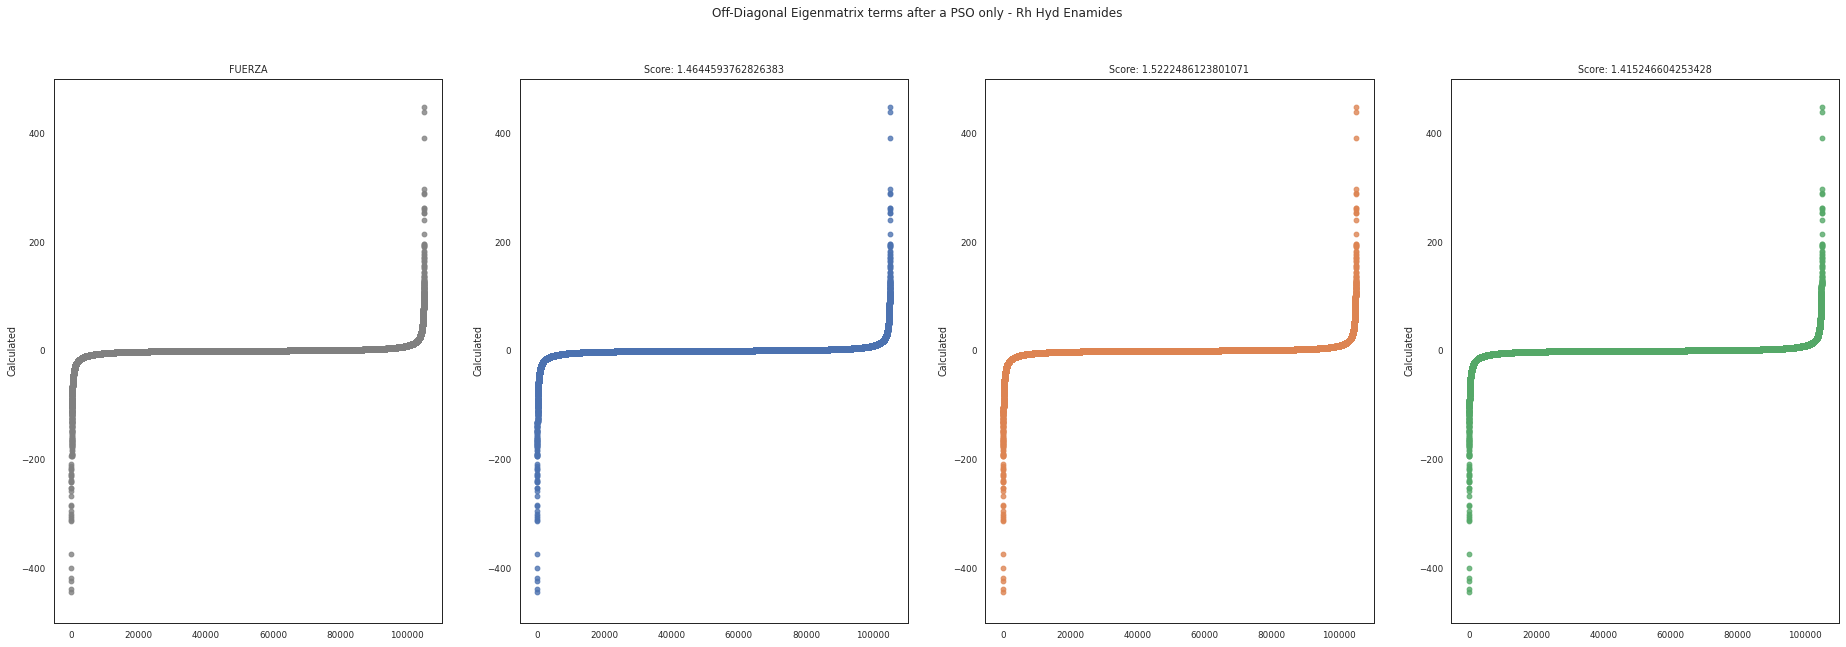

In [10]:
# Plot only off diagonal elements

fig, ax = plt.subplots(1, len(runs)+1, figsize=(32, 10))
fig.suptitle('Off-Diagonal Eigenmatrix terms after a PSO only - Rh Hyd Enamides')
palette = itertools.cycle(seaborn.color_palette())

off_diag_start = qf_scores.loc[qf_scores['Reference'] == 0.0000]
off_diag_start = off_diag_start.sort_values(by='Calculated', ignore_index=True)
seaborn.regplot(data=off_diag_start, x=off_diag_start.index, label='FF', y=score_cols[3], fit_reg=False, ax=ax[0], color='gray')
ax[0].set_title('FUERZA')
ax[0].set_ylim(top=500, bottom=-500)

for i, run in enumerate(runs):
    off_diag = run.loc[run['Reference'] == 0.0000]
    off_diag = off_diag.sort_values(by='Calculated', ignore_index=True)

    color = next(palette)
    seaborn.regplot(data=off_diag, x=off_diag.index, label='FF', y=score_cols[3], fit_reg=False, ax=ax[i+1], color=color)
    ax[i+1].set_title('Score: '+str(final_scores[i]))
    ax[i+1].set_ylim(top=500, bottom=-500)

plt.show()


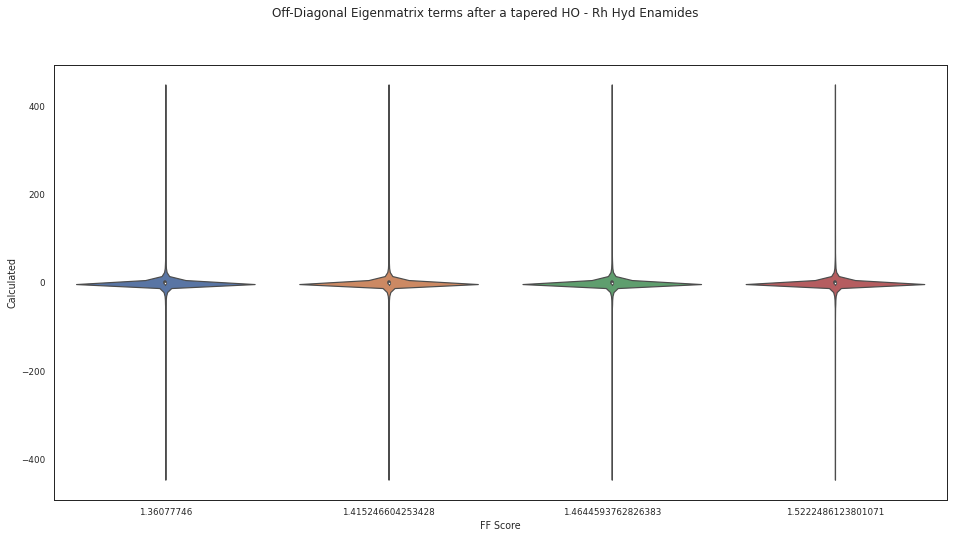

In [11]:
# VIOLIN Plot only off diagonal elements

fig, ax = plt.subplots(1, 1, figsize=(16, 8))
fig.suptitle('Off-Diagonal Eigenmatrix terms after a tapered HO - Rh Hyd Enamides')
off_diag_merged = pd.concat([run.loc[run['Reference'] == 0.0000] for run in runs])
off_diag_merged = pd.concat([off_diag_merged, off_diag_start])
off_diag_merged = off_diag_merged.sort_values(by='Calculated')

seaborn.violinplot(data=off_diag_merged, x='FF', y=score_cols[3])
ax.set_xlabel('FF Score')
plt.show()

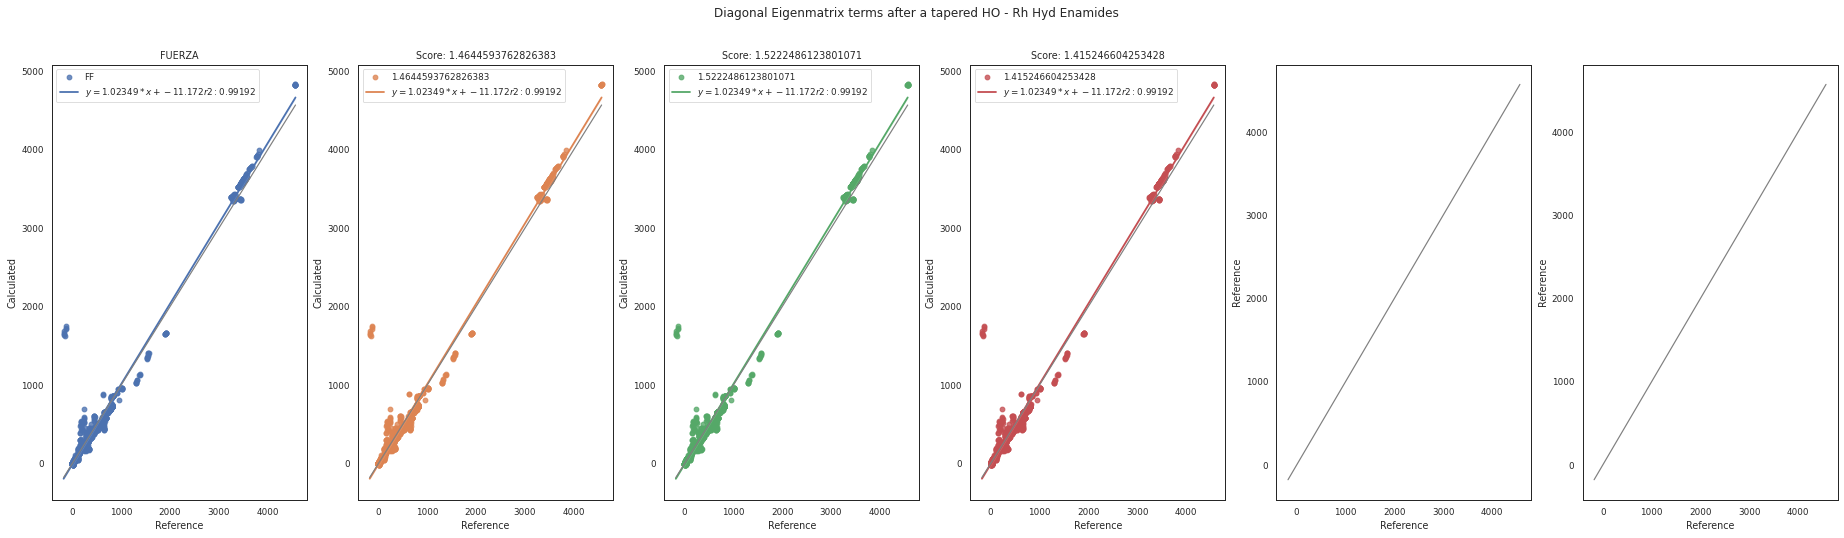

In [12]:
# Plot Diagonal Elements with a linear fit

fig, ax = plt.subplots(1, 6, figsize=(32,8))
fig.suptitle('Diagonal Eigenmatrix terms after a tapered HO - Rh Hyd Enamides')
palette = itertools.cycle(seaborn.color_palette())

diag = qf_scores.loc[qf_scores['Reference'] != 0.0000]
slope, intercept, r2, pv, se = stats.linregress(diag['Reference'], diag['Calculated'])

seaborn.regplot(data=diag, y='Calculated', x='Reference', color=next(palette), label='FF', line_kws={'label':'$y=%3.7s*x+%3.7s   r2:%3.7s$'%(slope, intercept, r2)}, ax=ax[0])
ax[0].legend()
ax[0].set_title('FUERZA')

for i, run in enumerate(runs):
    diag = run.loc[run['Reference'] != 0.0000]
    slope, intercept, r2, pv, se = stats.linregress(diag['Reference'], diag['Calculated'])
    
    seaborn.regplot(data=diag, y='Calculated', x='Reference', color=next(palette), label=final_scores[i], line_kws={'label':'$y=%3.7s*x+%3.7s   r2:%3.7s$'%(slope, intercept, r2)}, ax=ax[i+1])

    ax[i+1].legend()
    ax[i+1].set_title('Score: '+str(final_scores[i]))

for a in ax:
    seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=a)

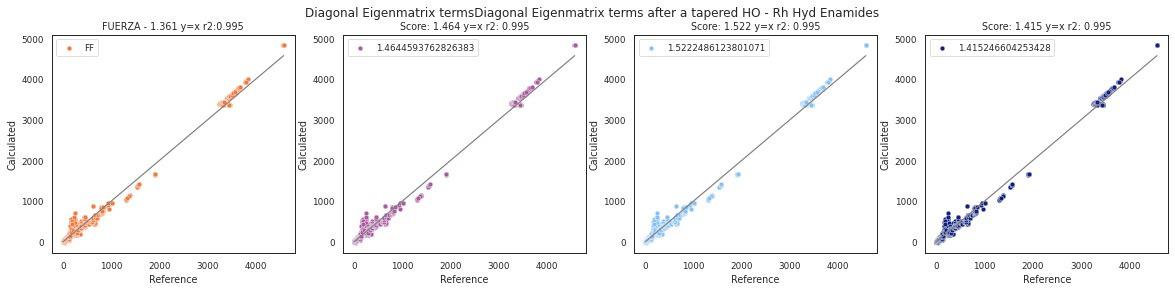

In [13]:
from tools.ff_plotting import *

linear_fit_diag_scores(qf_scores, fuerza_score, runs, final_scores, 'Diagonal Eigenmatrix terms after a tapered HO - Rh Hyd Enamides')

In [14]:
%matplotlib inline
# Plot FCs

bonds = []
angles = []

for directory, score in zip(directory_list, final_scores):
    bonds.append(pd.read_csv(os.path.join(base_directory, directory, 'rh_qf_ho_end.fld'), skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=score))
    angles.append(pd.read_csv(os.path.join(base_directory, directory, 'rh_qf_ho_end.fld'), skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=score))


3
["[1 2 '1']", "[2 3 '1']", "[2 3 'a1']", "[2 4 '1']", "[2 6 '1']", "[2 9 '1']", "[4 5 '1']", "[5 6 '1']"]


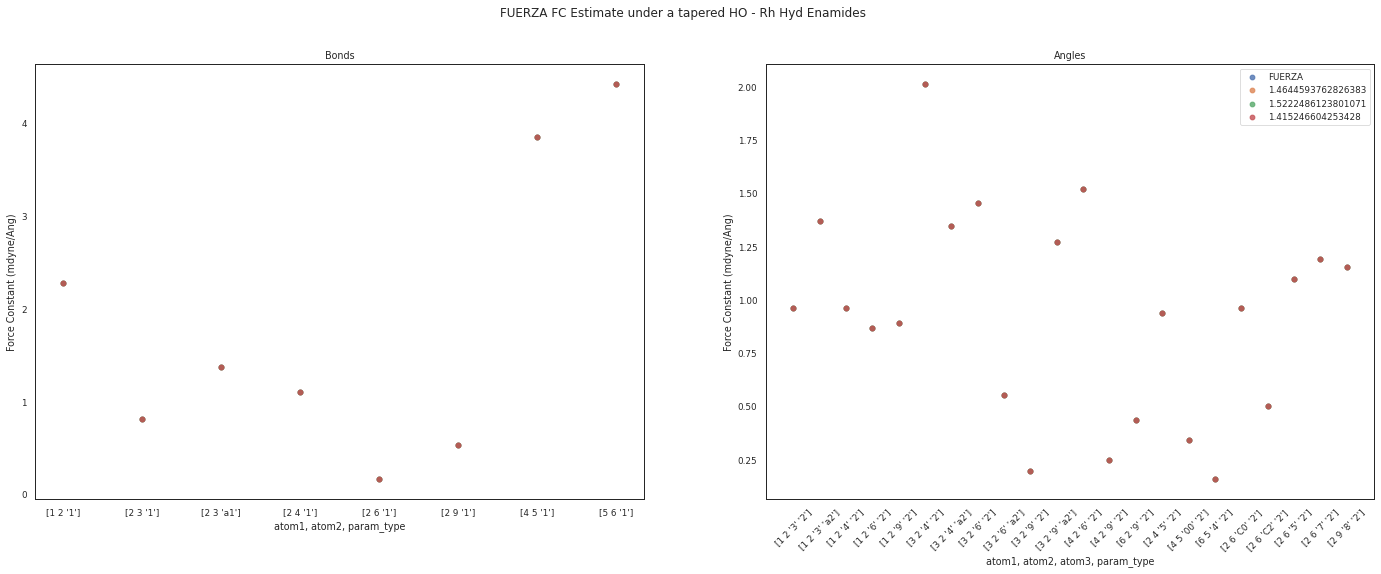

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')
ax[0].set_title('Bonds')
ax[1].set_title('Angles')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=bond_start, label='FUERZA', x = bond_start.index, y="Force Constant", fit_reg=False, ax=ax[0], color=color)
seaborn.regplot(data=angle_start, label='FUERZA', x = angle_start.index, y="Force Constant", fit_reg=False, ax=ax[1], color=color)
print(len(bonds))
bond_labels = bonds[i][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[i][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]
print(bond_labels)
for i in range(len(directory_list)):
    color = next(palette)
    seaborn.regplot(data=bonds[i], label=final_scores[i], x = bond_labels, y="Force Constant", fit_reg=False, ax=ax[0], color=color)
    seaborn.regplot(data=angles[i], label=final_scores[i], x = angles_labels, y="Force Constant", fit_reg=False, ax=ax[1], color=color)

plt.xticks(rotation=45)
ax[1].legend()
ax[0].set_ylabel('Force Constant (mdyne/Ang)')
ax[1].set_ylabel('Force Constant (mdyne/Ang)')
ax[0].set_xlabel('atom1, atom2, param_type')
ax[1].set_xlabel('atom1, atom2, atom3, param_type')
plt.show()

["[1 2 '1']", "[2 3 '1']", "[2 3 'a1']", "[2 4 '1']", "[2 6 '1']", "[2 9 '1']", "[4 5 '1']", "[5 6 '1']"]
['1860', '1861', '1862', '1863', '1864', '1865', '1866', '1867', '1868', '1869', '1870', '1871', '1872', '1873', '1874', '1875', '1876', '1877', '1878', '1879', '1880', '1881', '1882', '1883', '1884', '1885', '1886', '1887', '1888', '1889', '1912']
31


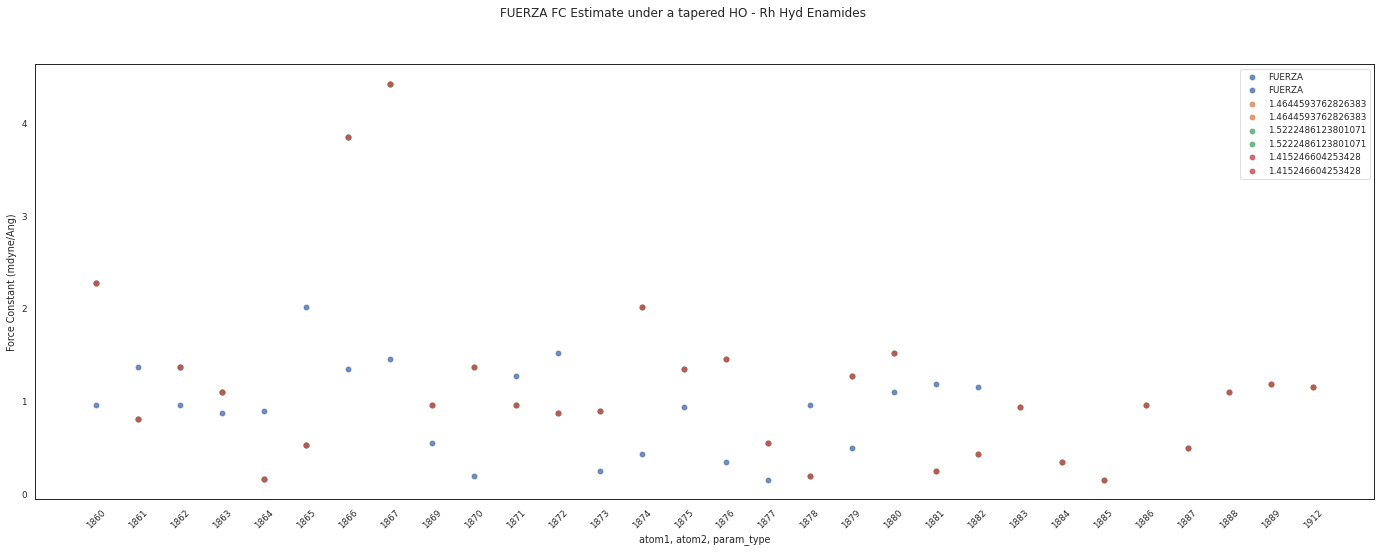

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=bond_start, label='FUERZA', x = bond_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
seaborn.regplot(data=angle_start, label='FUERZA', x = angle_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
bond_labels = bonds[i][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[i][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]
print(bond_labels)
rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(rows)
print(len(rows))
for i in range(len(directory_list)):
    color = next(palette)
    seaborn.regplot(data=bonds[i], label=final_scores[i], x = rows[:8], y="Force Constant", fit_reg=False, ax=ax, color=color)
    seaborn.regplot(data=angles[i], label=final_scores[i], x = rows[9:], y="Force Constant", fit_reg=False, ax=ax, color=color)

plt.xticks(rotation=45)
ax.legend()
ax.set_ylabel('Force Constant (mdyne/Ang)')
ax.set_xlabel('atom1, atom2, param_type')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/mfarrugi/repos/q2mm/rh-hybrid/conv_crit/local_best_x/500_iter_max_run/1/hybrid_opt_history.bin'

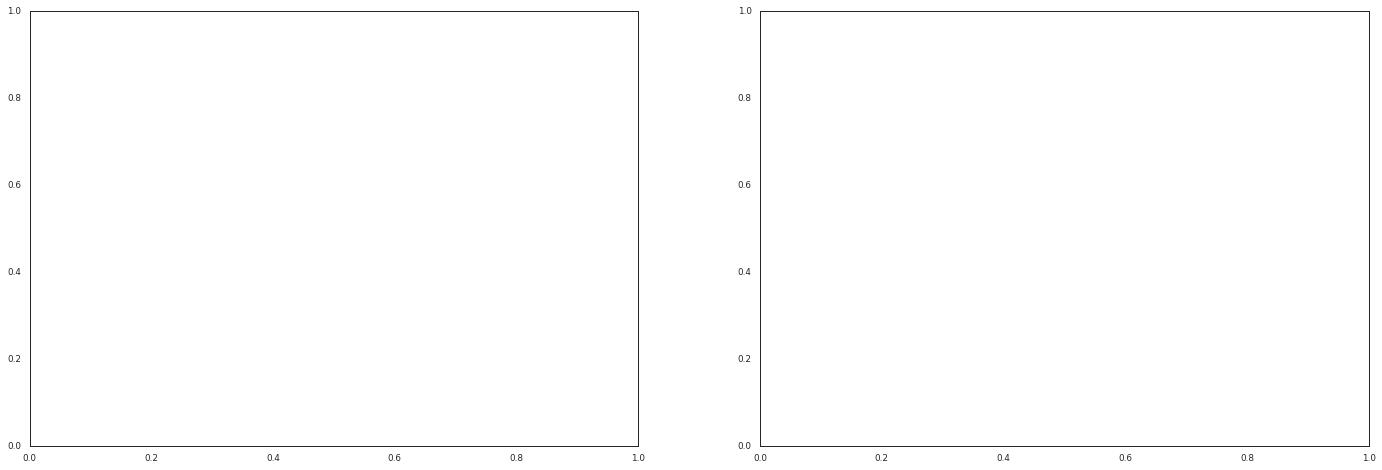

In [17]:
#plot final x
%matplotlib inline

def plot_last_x(history:dict, rows:list, title:str=''):
    fig, ax = plt.subplots(1, 1, figsize=(24, 8))
    fig.suptitle('Force Constants'+title)

    X_history = history["X"]
    last_X = X_history[-1]
    palette = itertools.cycle(seaborn.color_palette())

    for i, particle in enumerate(last_X):
        color = next(palette)
        seaborn.regplot(x=rows, y=particle, fit_reg=False, label=i, ax=ax, color=color)

    ax.legend()
    ax.set_ylabel('Force Constant (mdyne/Ang)')
    plt.show()

fig, ax = plt.subplots(1, 2, figsize=(24, 8))
swarm_history_file = open(os.path.join(base_directory, '1', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(ax[0]._get_lines.prop_cycler)['color']

rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
swarm_history_file = open(os.path.join(base_directory, '2', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(ax[0]._get_lines.prop_cycler)['color']

rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
swarm_history_file = open(os.path.join(base_directory, '3', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(ax[0]._get_lines.prop_cycler)['color']

rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=bond_start, label='FUERZA', x = bond_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
seaborn.regplot(data=angle_start, label='FUERZA', x = angle_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
bond_labels = bonds[i][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[i][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]
print(bond_labels)
rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(rows)
print(len(rows))
color = next(palette)
for i in range(len(directory_list)):
    seaborn.regplot(data=bonds[i], label=final_scores[i], x = rows[:8], y="Force Constant", fit_reg=False, ax=ax, color=color)
    seaborn.regplot(data=angles[i], label=final_scores[i], x = rows[9:], y="Force Constant", fit_reg=False, ax=ax, color=color)

plt.xticks(rotation=45)


#plot final x

def plot_last_x(history:dict, rows:list, title:str=''):

    X_history = history["X"]
    last_X = X_history[-1]

    for i, particle in enumerate(last_X):
        seaborn.regplot(x=rows, y=particle, fit_reg=False, label=i, ax=ax, color=color)

    ax.legend()
    ax.set_ylabel('Force Constant (mdyne/Ang)')
    plt.show()

swarm_history_file = open(os.path.join(base_directory, '1', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(palette)

rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=bond_start, label='FUERZA', x = bond_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
seaborn.regplot(data=angle_start, label='FUERZA', x = angle_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
bond_labels = bonds[i][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[i][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]
print(bond_labels)
rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(rows)
print(len(rows))
color = next(palette)
for i in range(len(directory_list)):
    seaborn.regplot(data=bonds[i], label=final_scores[i], x = rows[:8], y="Force Constant", fit_reg=False, ax=ax, color=color)
    seaborn.regplot(data=angles[i], label=final_scores[i], x = rows[9:], y="Force Constant", fit_reg=False, ax=ax, color=color)

plt.xticks(rotation=45)


#plot final x

def plot_last_x(history:dict, rows:list, title:str=''):

    X_history = history["X"]
    last_X = X_history[-1]
    print(last_X)

    for i, particle in enumerate(last_X):
        seaborn.regplot(x=rows, y=particle, fit_reg=False, label=i, ax=ax, color=color)

    ax.legend()
    ax.set_ylabel('Force Constant (mdyne/Ang)')
    plt.show()

swarm_history_file = open(os.path.join(base_directory, '1', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(palette)

rows = [*bond_rows, *angle_rows, 1911]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)


In [ ]:
plot_param_history(base_directory, directory_list, 15, '1875 history', num_iters, 1.36)

In [ ]:
plot_param_history(base_directory, directory_list, 14, '1875 history', num_iters, 1.36)

In [ ]:
plot_param_history_histogram(base_directory, directory_list, 15, '1875 history', num_iters, 1.36)

In [ ]:
plot_param_history_penalty(base_directory, directory_list, 15, '1875 history', num_iters, 1.36)

In [ ]:
plot_param_history_penalty(base_directory, directory_list, 1, '1875 history', num_iters, 1.36)

In [27]:
def plot_param_density_rug(base_direc:str, directories:list, param_index:int, title:str, cycle_iter_length:int, starting_score:float) -> list :
    fig, ax = plt.subplots(1, len(directories), figsize=(24, 8))
    fig.suptitle(title)
    ax[0].set_title('Param '+str(param_index)+' Throughout Parameterization')
    ax[1].set_title('Loss, aka Best Score Throughout Parameterization')

    ax[0].axhline(y=starting_score, color='gray')
    ax[1].axhline(y=starting_score, color='gray')

    final_scores = []

    for i, directory in enumerate(directories):

        swarm_history_file = open(os.path.join(base_direc, directory, 'hybrid_opt_history.bin'), 'rb')
        swarm_history = pickle.load(swarm_history_file)
        swarm_history_file.close()
        num_iters = len(swarm_history['Y'])
        num_ffs = len(swarm_history['Y'][0])
        color = next(ax[0]._get_lines.prop_cycler)['color']
        X_history = np.array(swarm_history['X'])
        #Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))
        param_history = pd.DataFrame(X_history[:,:,param_index])
        x_vals = X_history[:,3,param_index]
        print(swarm_history.keys())
        print(swarm_history['best_x'])
        #gbest_x = np.reshape(swarm_history['best_x'], (num_iters, num_params))[:,param_index]
        #gbest_y = swarm_history['best_y']
        y_vals = np.reshape(swarm_history['Y'], (num_iters, num_ffs))[:,3]
        #print(y_vals)
        #seaborn.scatterplot(x=x_vals, y=y_vals, ax=ax[i])
        #ax[i].set_ylim(top=3)
        aggregated_param_history = pd.DataFrame(X_history[:,:,param_index].flatten())
        seaborn.kdeplot(data=param_history,  color=color, ax=ax[i])
        seaborn.kdeplot(data=aggregated_param_history,  color=color, ax=ax[i])
        #param_history.plot.kde(ax=ax[i])
        seaborn.rugplot(x=swarm_history['best_x'][param_index], ax=ax[i])


    ax[0].legend()

    plt.show()
    return

In [ ]:
plot_param_density_rug(base_directory, directory_list[:2], 1, '1875 history', num_iters, 1.36)

In [30]:
seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080', '#528D6A']
zesty2 = ['#F65300', '#6e3a69', '#6793bc', '#081142', '#39634a'] #c86431
zesty_palette = seaborn.color_palette(palette=zesty)
zesty2_palette = seaborn.color_palette(palette=zesty2)
edges = itertools.cycle(zesty2_palette)
palette = itertools.cycle(zesty_palette)

#AGGREGATED ONLY

def plot_params_density(base_direc:str, directories:list, title:str, cycle_iter_length:int, starting_score:float) -> list :
    fig, ax = plt.subplots(6, 6, figsize=(64,64))
    fig.suptitle("Aggregated Histogram")
    fig.tight_layout()


    final_scores = []
    for i, directory in enumerate(directories):
        color = next(palette)
        swarm_history_file = open(os.path.join(base_direc, directory, 'hybrid_opt_history.bin'), 'rb')
        swarm_history = pickle.load(swarm_history_file)
        swarm_history_file.close()
        num_iters = len(swarm_history['Y'])
        num_ffs = len(swarm_history['Y'][0])
        X_history = np.array(swarm_history['X'])
        Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))
        final_scores.append(swarm_history['best_y'])
        final_scores.append(swarm_history['best_y'])

        for param_index in range(num_params):
            #print(int(param_index/6), param_index%6)
            #color = next(ax[int(param_index/6), param_index%6]._get_lines.prop_cycler)['color']
            param_history = pd.DataFrame(X_history[:,:,param_index])
            aggregated_param_history = pd.DataFrame(X_history[:,:,param_index].flatten())
            #seaborn.kdeplot(data=param_history,  color=color, ax=ax[int(param_index/6), param_index%6])
            seaborn.kdeplot(data=aggregated_param_history.squeeze(),  color=color, fill=True, linewidth=7, label=swarm_history['best_y'], ax=ax[int(param_index/6), param_index%6])
            ax[int(param_index/6), param_index%6].axvline(x=swarm_history['best_x'][param_index], linewidth=7, color = color)
            #seaborn.scatterplot(x=swarm_history['best_x'][param_index], y=[0.1], color = color, s=150, ax=ax[int(param_index/6), param_index%6])
            #seaborn.rugplot(x=swarm_history['best_x'][param_index], ax=ax[i])
            if param_index == num_params-1:
                #ax[int(param_index/6), param_index%6].legend()
                ax[int(param_index/6), param_index%6].set_title(param_index)
            if i==len(directories)-1:
                ax[int(param_index/6), param_index%6].legend(final_scores)


    plt.show()
    return

In [ ]:
plot_params_density(base_directory, directory_list, 'history', num_iters, 1.36)

In [32]:
seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080', '#528D6A']
zesty2 = ['#F65300', '#6e3a69', '#6793bc', '#081142', '#39634a'] #c86431
zesty_palette = seaborn.color_palette(palette=zesty)
zesty2_palette = seaborn.color_palette(palette=zesty2)
edges = itertools.cycle(zesty2_palette)
palette = itertools.cycle(zesty_palette)

#INDIVIDUAL ONLY

def plot_params_density(base_direc:str, directories:list, title:str, cycle_iter_length:int, starting_score:float) -> list :
    fig, ax = plt.subplots(6, 6, figsize=(64,64))


    final_scores = []
    for i, directory in enumerate(directories):
        color = next(palette)
        swarm_history_file = open(os.path.join(base_direc, directory, 'hybrid_opt_history.bin'), 'rb')
        swarm_history = pickle.load(swarm_history_file)
        swarm_history_file.close()
        num_iters = len(swarm_history['Y'])
        num_ffs = len(swarm_history['Y'][0])
        X_history = np.array(swarm_history['X'])
        Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))

        for param_index in range(num_params):
            #print(int(param_index/6), param_index%6)
            #color = next(ax[int(param_index/6), param_index%6]._get_lines.prop_cycler)['color']
            param_history = pd.DataFrame(X_history[:,:,param_index])
            aggregated_param_history = pd.DataFrame(X_history[:,:,param_index].flatten())
            seaborn.kdeplot(data=param_history, linewidth=4,  palette=itertools.cycle([color, color, color, color, color, color, color, color, color, color, color]), ax=ax[int(param_index/6), param_index%6])
            for x in X_history[0,:,param_index]:
                ax[int(param_index/6), param_index%6].axvline(x=x, linewidth=2, linestyle='dashed', color = color)
            ax[int(param_index/6), param_index%6].axvline(x=swarm_history['best_x'][param_index], linewidth=4, color = color)
            #seaborn.scatterplot(x=X_history[0,:,param_index], y=[0.01]*10, marker='X', ax=ax[int(param_index/6), param_index%6], color = color)
            #seaborn.kdeplot(data=aggregated_param_history.squeeze(),  color=color, fill=True, ax=ax[int(param_index/6), param_index%6])
            #seaborn.rugplot(x=swarm_history['best_x'][param_index], ax=ax[i])
            if param_index == num_params-1:
                #ax[int(param_index/6), param_index%6].legend()
                ax[int(param_index/6), param_index%6].set_title(param_index)

    plt.show()
    return

In [ ]:
plot_params_density(base_directory, directory_list, 'history', num_iters, 1.36)

In [34]:
seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080', '#528D6A']
zesty2 = ['#F65300', '#6e3a69', '#6793bc', '#081142', '#39634a'] #c86431
zesty_palette = seaborn.color_palette(palette=zesty)
zesty2_palette = seaborn.color_palette(palette=zesty2)
edges = itertools.cycle(zesty2_palette)
palette = itertools.cycle(zesty_palette)

#AVERAGED ONLY - TODO

def plot_params_density(base_direc:str, directories:list, title:str, cycle_iter_length:int, starting_score:float) -> list :
    fig, ax = plt.subplots(6, 6, figsize=(64,64))


    final_scores = []
    for i, directory in enumerate(directories):
        color = next(palette)
        swarm_history_file = open(os.path.join(base_direc, directory, 'hybrid_opt_history.bin'), 'rb')
        swarm_history = pickle.load(swarm_history_file)
        swarm_history_file.close()
        num_iters = len(swarm_history['Y'])
        num_ffs = len(swarm_history['Y'][0])
        X_history = np.array(swarm_history['X'])
        Y_history = pd.DataFrame(np.array(swarm_history['Y']).reshape((num_iters, num_ffs)))

        for param_index in range(num_params):
            #print(int(param_index/6), param_index%6)
            #color = next(ax[int(param_index/6), param_index%6]._get_lines.prop_cycler)['color']
            param_history = pd.DataFrame(X_history[:,0,param_index])
            aggregated_param_history = pd.DataFrame(X_history[:,0,param_index].flatten())
            seaborn.kdeplot(data=param_history,  color=color, ax=ax[int(param_index/6), param_index%6])
            #seaborn.kdeplot(data=aggregated_param_history.squeeze(),  color=color, fill=True, ax=ax[int(param_index/6), param_index%6])
            #seaborn.rugplot(x=swarm_history['best_x'][param_index], ax=ax[i])
            if param_index == num_params-1: ax[int(param_index/6), param_index%6].legend()

    plt.show()
    return

In [ ]:
plot_params_density(base_directory, directory_list, 'history', num_iters, 1.36)

In [36]:
swarm_history_file = open(os.path.join(base_directory, '1', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['best_x'])
num_ffs = len(swarm_history['Y'][0])

could look at change in distribution over time along with pbest to see
look at indices before and after the pbest value changes to see if can rule out pbest social behavior as the reason or if can't eliminate that possibility

In [37]:
swarm_history_file = open(os.path.join(base_directory, '1', 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])

In [ ]:
plot_param_history_histogram3d(base_directory, directory_list, [5,7], 'history', num_iters, 1.36)

In [ ]:
final_scores = plot_history(base_directory, '1', 'FUERZA FC Estimate under HO - Rh Hyd Enamides', 300, fuerza_score)
plt.show()